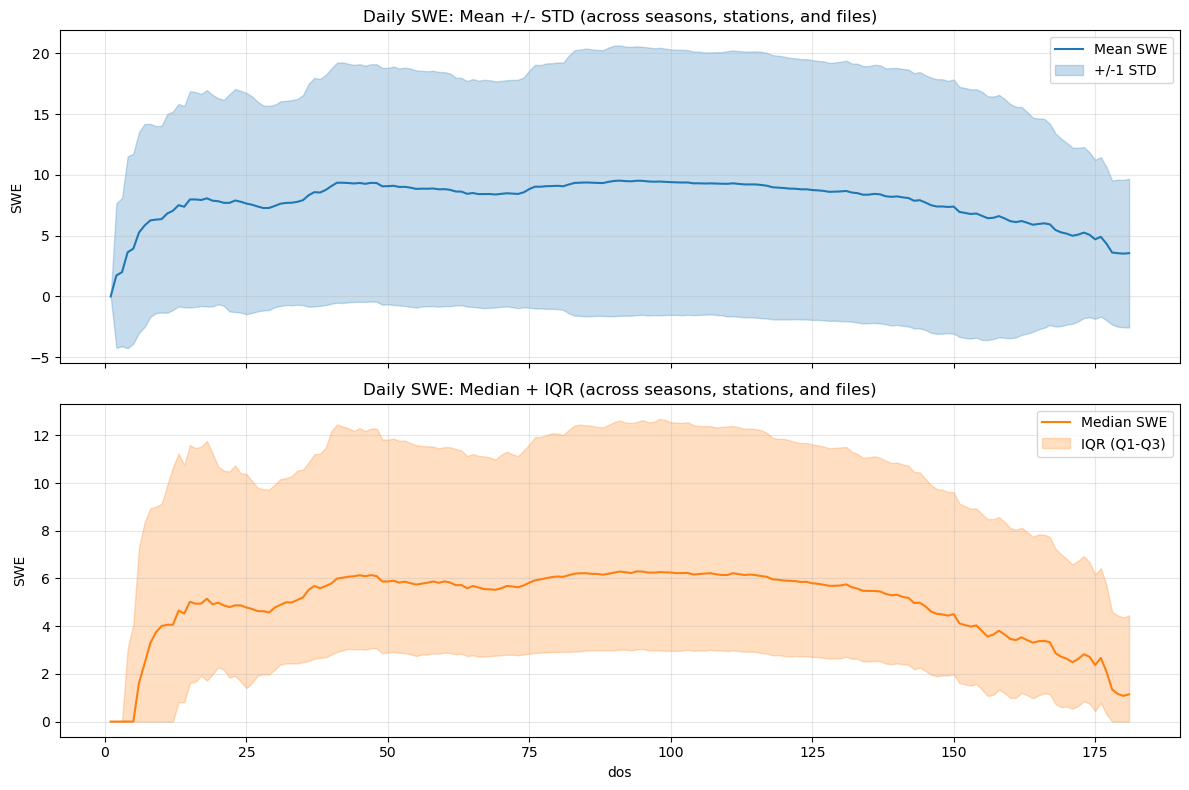

Skipped 53 file(s) due to incompatible SWE structure.


In [12]:
from pathlib import Path
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

data_dir = Path("/Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/batch_comparison_output/netcdf_with_obs")
nc_files = sorted(data_dir.glob("*.nc"))

if not nc_files:
    raise FileNotFoundError(f"No .nc files found in: {data_dir}")

# Include 'dos' (day-of-season), which is used in these comparison files.
preferred_day_dims = ["dos", "day", "time", "date", "doy"]
all_samples = []
x = None
expected_day_len = None
skipped_files = []

for path in nc_files:
    with xr.open_dataset(path) as ds_one:
        # Find SWE variable (prefer exact "swe", otherwise any variable containing "swe")
        if "swe" in ds_one.data_vars:
            swe_one = ds_one["swe"]
        else:
            candidates = [v for v in ds_one.data_vars if "swe" in v.lower()]
            if not candidates:
                skipped_files.append(f"{path.name}: no SWE-like variable")
                continue
            swe_one = ds_one[candidates[0]]

        current_day_dim = next((d for d in preferred_day_dims if d in swe_one.dims), None)
        if current_day_dim is None:
            skipped_files.append(f"{path.name}: no day-like dimension in {swe_one.dims}")
            continue

        day_len = swe_one.sizes[current_day_dim]
        if x is None:
            expected_day_len = day_len
            x = (
                swe_one[current_day_dim].values
                if current_day_dim in swe_one.coords
                else np.arange(expected_day_len)
            )
        elif day_len != expected_day_len:
            skipped_files.append(
                f"{path.name}: {current_day_dim} length {day_len} != expected {expected_day_len}"
            )
            continue

        # Move day first, then flatten all other dimensions into a sample axis.
        ordered_dims = [current_day_dim] + [d for d in swe_one.dims if d != current_day_dim]
        arr = swe_one.transpose(*ordered_dims).values
        arr_2d = arr.reshape(expected_day_len, -1)
        all_samples.append(arr_2d)

if not all_samples:
    details = "\n".join(skipped_files[:10])
    raise KeyError(f"No compatible SWE data found across files.\n{details}")

samples = np.concatenate(all_samples, axis=1)

mean_daily = np.nanmean(samples, axis=1)
std_daily = np.nanstd(samples, axis=1)
median_daily = np.nanmedian(samples, axis=1)
q1_daily = np.nanquantile(samples, 0.25, axis=1)
q3_daily = np.nanquantile(samples, 0.75, axis=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Mean +/- STD
axes[0].plot(x, mean_daily, label="Mean SWE", color="tab:blue")
axes[0].fill_between(
    x,
    mean_daily - std_daily,
    mean_daily + std_daily,
    color="tab:blue",
    alpha=0.25,
    label="+/-1 STD",
)
axes[0].set_title("Daily SWE: Mean +/- STD (across seasons, stations, and files)")
axes[0].set_ylabel("SWE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Median + IQR
axes[1].plot(x, median_daily, label="Median SWE", color="tab:orange")
axes[1].fill_between(
    x,
    q1_daily,
    q3_daily,
    color="tab:orange",
    alpha=0.25,
    label="IQR (Q1-Q3)",
)
axes[1].set_title("Daily SWE: Median + IQR (across seasons, stations, and files)")
axes[1].set_xlabel("dos")
axes[1].set_ylabel("SWE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if skipped_files:
    print(f"Skipped {len(skipped_files)} file(s) due to incompatible SWE structure.")

In [15]:
data = xr.open_dataset("/Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/batch_comparison_output/netcdf_with_obs/Adelboden_dsnow_allseasons_with_obs.nc")

In [16]:
data

<xarray.Dataset> Size: 1MB
Dimensions:     (layer: 26, dos: 181, season: 6)
Coordinates:
  * season      (season) int32 24B 2017 2018 2019 2020 2021 2022
  * dos         (dos) int32 724B 1 2 3 4 5 6 7 8 ... 175 176 177 178 179 180 181
  * layer       (layer) int32 104B 1 2 3 4 5 6 7 8 9 ... 19 20 21 22 23 24 25 26
Data variables:
    HS          (layer, dos, season) float64 226kB ...
    SWE_layers  (layer, dos, season) float64 226kB ...
    AGE         (layer, dos, season) float64 226kB ...
    RHO         (layer, dos, season) float64 226kB ...
    OVB         (layer, dos, season) float64 226kB ...
    SWE_total   (dos, season) float64 9kB ...
    HS_meas_m   (dos, season) float64 9kB ...
    SWE_obs_mm  (dos, season) float64 9kB ...
Attributes:
    season_window_start_mmdd:  11-01
    season_window_end_mmdd:    04-30
    dos_definition:            dos = 1 corresponds to Nov 1 of (season-1); do...

In [17]:
import pandas as pd

# Build a file table and split by model keyword in the filename.
records = []
for path in nc_files:
    fname = path.name
    if "_dsnow_" in fname:
        model = "dsnow"
    elif "_hs2swe_" in fname:
        model = "hs2swe"
    else:
        model = "other"

    station = (
        fname.replace("_dsnow_allseasons_with_obs.nc", "")
        .replace("_hs2swe_allseasons_with_obs.nc", "")
    )

    records.append(
        {
            "file_name": fname,
            "file_path": str(path),
            "station": station,
            "model": model,
        }
    )

files_df = pd.DataFrame(records).sort_values(["model", "station", "file_name"]).reset_index(drop=True)

dsnow_files_df = files_df[files_df["model"] == "dsnow"].reset_index(drop=True)
hs2swe_files_df = files_df[files_df["model"] == "hs2swe"].reset_index(drop=True)

print(f"dsnow files: {len(dsnow_files_df)}")
print(f"hs2swe files: {len(hs2swe_files_df)}")

# Quick preview
display(dsnow_files_df.head())
display(hs2swe_files_df.head())

dsnow files: 55
hs2swe files: 53


,file_name,file_path,station,model
0,Adelboden_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Adelboden,dsnow
1,Binn_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Binn,dsnow
2,Bivio_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Bivio,dsnow
3,Bosco_Gurin_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Bosco_Gurin,dsnow
4,Bourg_St_Pierre_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Bourg_St_Pierre,dsnow


,file_name,file_path,station,model
0,Adelboden_hs2swe_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Adelboden,hs2swe
1,Binn_hs2swe_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Binn,hs2swe
2,Bivio_hs2swe_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Bivio,hs2swe
3,Bosco_Gurin_hs2swe_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Bosco_Gurin,hs2swe
4,Bourg_St_Pierre_hs2swe_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Bourg_St_Pierre,hs2swe


In [18]:
dsnow_files_df

,file_name,file_path,station,model
0,Adelboden_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Adelboden,dsnow
1,Binn_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Binn,dsnow
2,Bivio_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Bivio,dsnow
3,Bosco_Gurin_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Bosco_Gurin,dsnow
4,Bourg_St_Pierre_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Bourg_St_Pierre,dsnow
5,Braunwald_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Braunwald,dsnow
6,Davos_Flueelastr_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Davos_Flueelastr,dsnow
7,Davos_Flueelastr_dsnow_dsnow_allseasons_with_o...,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Davos_Flueelastr_dsnow,dsnow
8,Davos_Flueelastr_dsnow_hs2swe_allseasons_with_...,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Davos_Flueelastr_dsnow,dsnow
9,Felbertauern_dsnow_allseasons_with_obs.nc,/Users/jakobwerkgarner/code/mt_dsnow/model_dif...,Felbertauern,dsnow


In [20]:
from pathlib import Path


def load_swe_group_to_xarray(df, group_name):
    swe_datasets = []
    source_names = []
    failed = []

    for file_path in df["file_path"]:
        try:
            ds = xr.open_dataset(file_path)

            if "swe" in ds.data_vars:
                swe_name = "swe"
            else:
                cands = [v for v in ds.data_vars if "swe" in v.lower()]
                if not cands:
                    failed.append((file_path, "no SWE-like variable"))
                    ds.close()
                    continue
                swe_name = cands[0]

            # Keep only SWE to avoid expensive alignment on unrelated variables.
            swe_ds = ds[[swe_name]].rename({swe_name: "swe"})
            swe_datasets.append(swe_ds)
            source_names.append(Path(file_path).name)

        except Exception as exc:
            failed.append((file_path, str(exc)))

    if not swe_datasets:
        raise RuntimeError(f"No readable SWE datasets found for group: {group_name}")

    combined = xr.concat(
        swe_datasets,
        dim="source_file",
        data_vars="all",
        coords="minimal",
        compat="override",
        join="outer",
        combine_attrs="drop_conflicts",
    ).assign_coords(source_file=("source_file", source_names))

    print(
        f"{group_name}: loaded {len(source_names)} files, "
        f"failed {len(failed)}, dims={dict(combined.sizes)}"
    )

    if failed:
        print(f"First failures in {group_name}:")
        for file_path, err in failed[:5]:
            print(f"- {Path(file_path).name}: {err}")

    return combined, failed


dsnow_xr, dsnow_failed = load_swe_group_to_xarray(dsnow_files_df, "dsnow")
hs2swe_xr, hs2swe_failed = load_swe_group_to_xarray(hs2swe_files_df, "hs2swe")

print("\nCreated:")
print("- dsnow_xr")
print("- hs2swe_xr")

# Quick check
dsnow_xr.swe, hs2swe_xr.swe

dsnow: loaded 55 files, failed 0, dims={'source_file': 55, 'layer': 71, 'dos': 182, 'season': 38}
hs2swe: loaded 53 files, failed 0, dims={'source_file': 53, 'season': 38, 'dos': 182}

Created:
- dsnow_xr
- hs2swe_xr


(<xarray.DataArray 'swe' (source_file: 55, layer: 71, dos: 182, season: 38)> Size: 216MB
 array([[[[        nan,         nan,         nan, ...,  0.        ,
            0.        ,  0.        ],
          [        nan,         nan,         nan, ...,  0.        ,
            0.        ,  0.        ],
          [        nan,         nan,         nan, ...,  0.        ,
            0.        ,  0.        ],
          ...,
          [        nan,         nan,         nan, ...,  0.        ,
            0.        ,  0.        ],
          [        nan,         nan,         nan, ...,  0.        ,
            0.        ,  0.        ],
          [        nan,         nan,         nan, ...,         nan,
                   nan,         nan]],
 
         [[        nan,         nan,         nan, ...,         nan,
                   nan,         nan],
          [        nan,         nan,         nan, ...,         nan,
                   nan,         nan],
          [        nan,         nan,         

In [ ]:
def running_stats_by_dos(da, window=7, day_dim="dos"):
    if day_dim not in da.dims:
        raise ValueError(f"{day_dim!r} not found in dims: {da.dims}")

    smooth = da.rolling({day_dim: window}, center=True, min_periods=1).mean()

    sample_dims = [d for d in smooth.dims if d != day_dim]
    if sample_dims:
        smooth = smooth.stack(sample=sample_dims)
    else:
        smooth = smooth.expand_dims(sample=[0])

    mean = smooth.mean("sample", skipna=True)
    std = smooth.std("sample", skipna=True)
    return mean, std


window = 7

dsnow_mean_rm, dsnow_std_rm = running_stats_by_dos(dsnow_xr["swe"], window=window)
hs2swe_mean_rm, hs2swe_std_rm = running_stats_by_dos(hs2swe_xr["swe"], window=window)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(dsnow_mean_rm["dos"], dsnow_mean_rm, color="tab:blue", label=f"dsnow mean ({window}-day running)")
ax.fill_between(
    dsnow_mean_rm["dos"].values,
    (dsnow_mean_rm - dsnow_std_rm).values,
    (dsnow_mean_rm + dsnow_std_rm).values,
    color="tab:blue",
    alpha=0.2,
    label="dsnow ±1 std",
)

ax.plot(hs2swe_mean_rm["dos"], hs2swe_mean_rm, color="tab:orange", label=f"hs2swe mean ({window}-day running)")
ax.fill_between(
    hs2swe_mean_rm["dos"].values,
    (hs2swe_mean_rm - hs2swe_std_rm).values,
    (hs2swe_mean_rm + hs2swe_std_rm).values,
    color="tab:orange",
    alpha=0.2,
    label="hs2swe ±1 std",
)

ax.set_title("Running mean SWE over dos with standard deviation")
ax.set_xlabel("dos")
ax.set_ylabel("SWE")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

(array([173026.,  14194.,   5600.,   3673.,   1718.,   2423.,    413.,
           341.,    831.,   1117.]),
 array([  0.        ,  40.74753456,  81.49506912, 122.24260368,
        162.99013824, 203.73767279, 244.48520735, 285.23274191,
        325.98027647, 366.72781103, 407.47534559]),
 <BarContainer object of 10 artists>)

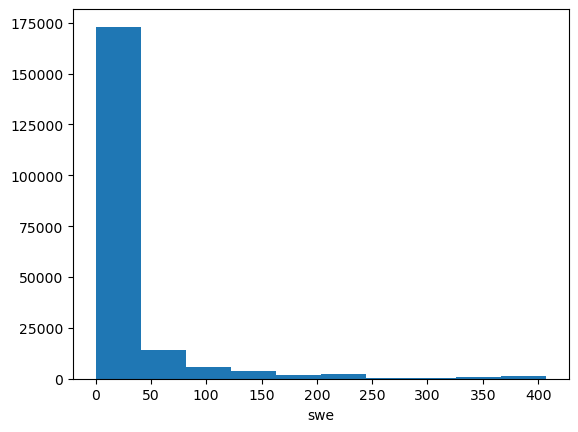